In [63]:
import glob #importing glob library
import matplotlib.pyplot as plt #Need for plotting at the end
import numpy as np #numpi

In [64]:
import astropy
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits
from astropy.utils import data
from astropy.wcs import wcs #everything above is for reading FIT/FITS
from astropy.visualization import (AsinhStretch, LogStretch, 
                                  PercentileInterval, ImageNormalize, simple_norm, ZScaleInterval) #tools for visualizing large range of fits data

In [65]:
from astropy.nddata import CCDData
import pandas as pd
from astropy.coordinates import SkyCoord #don't remeber if any of this is needed

import ipywidgets as widgets
!pip install ipycanvas
from IPython.display import display #widgets/canvas is how the image gets displayed/interacted with

In [66]:
!pip install astropy astroalign numpy
import astroalign as aa #JJ said we would make our own huzzah

In [67]:
from ipycanvas import Canvas
from PIL import Image
from PIL import ImageTk
from tkinter import * #more canvas functions we will need

In [88]:
import astropy.units as u
from astropy.utils import data
!pip install spectral-cube
from spectral_cube import SpectralCube #turned out to be not needed but might need in the future


   ---------------------------------------- 0/3 [radio-beam]
   ---------------------------------------- 0/3 [radio-beam]
   ------------- -------------------------- 1/3 [casa-formats-io]
   ------------- -------------------------- 1/3 [casa-formats-io]
   ------------- -------------------------- 1/3 [casa-formats-io]
   ------------- -------------------------- 1/3 [casa-formats-io]
   ------------- -------------------------- 1/3 [casa-formats-io]
   ------------- -------------------------- 1/3 [casa-formats-io]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ------------- 2/3 [spectral-cube]
   -------------------------- ---

In [114]:
image_data = fits.open('C:/Users/isaac/Downloads/flat_fits_1.fits')[0].data #reads FITS data from file
interval = ZScaleInterval(n_samples=1000, contrast=0.25) #interval is created by sampling the file
vmin,vmax = interval.get_limits(image_data) #creates min and max value based on defined interval

#This process is necessary because python will just assign the highest value to white and the lowest to black, so most of the details in unedited 
#data will become black due to the insanely high counts for a few very bright stars

if vmax <= vmin or (vmax - vmin) < 1e-5: #safeguard - if the interval is way to big it will just reset to 99%
    interval = PercentileInterval(99)
    vmin, vmax = interval.get_limits(image_data) #the top and bottom 0.5% will be cut off

data_range = vmax - vmin #defining range of data that will be displayed
vmin_adjusted = vmin +(data_range * 0.18) #cutting off more from the bottom depending on how big the range is

clipped_image_data = np.clip(image_data, vmin_adjusted, vmax) #clipping off edges of data based on limits
normalized = (clipped_image_data - vmin_adjusted) / (vmax - vmin_adjusted) #normalization fromula usually done by .plt
canvas_image = (normalized * 255).astype(np.uint8) #this is needed to turn FITS data into color values that canvas can read

In [115]:
root = Tk()
root.title("Pick Star")
root.geometry('900x700') #creating basic features of the canvas

pil_img = Image.fromarray(canvas_image, mode='L') #turns array into canvas image, L means greyscale for some reason
tk_img = ImageTk.PhotoImage(image=pil_img, master=root) #creating image while referring back to previously defined properties

hbar = Scrollbar(root, orient=HORIZONTAL)
hbar.pack(side=BOTTOM, fill=X)
vbar = Scrollbar(root, orient=VERTICAL)
vbar.pack(side=RIGHT, fill=Y) #if image is bigger than moniter than you have problem, thus we make it small in line three and give it scroll bars here

canvas = Canvas(root, width=800, height=600, #smaller than defined before to make room for scroll bars
                scrollregion=(0, 0, canvas_image.shape[1], canvas_image.shape[0]),
                xscrollcommand=hbar.set, yscrollcommand=vbar.set) #just setting up the function of scrolling
canvas.pack(side=LEFT, expand=True, fill=BOTH)

hbar.config(command=canvas.xview)
vbar.config(command=canvas.yview)
canvas.create_image(0, 0, anchor="nw", image=tk_img) #actually puting the image on screen

chosen_x = [0] #defining variables for coordinates
chosen_y = [0]

def give_coords(event):
    true_x = int(canvas.canvasx(event.x)) #these adjust for the fact that you have scrolled which would otherwise not be accounted for
    true_y = int(canvas.canvasy(event.y))
    height, width = canvas_image.shape #pulling the dimensions to account for clicking outside of the image
    
    if 0 <= true_x < width and 0 <= true_y < height: #this is only true if your mouse is within the image so there's no errors when you click off
        pixel_value = image_data[true_y, true_x] #takes the intensity of the pixel from before it was normalized
        print(f"FITS Coord: ({true_x}, {true_y}) | Intensity: {pixel_value}       ", end="\r") #shows everything when you click
        chosen_x[0] = true_x #assigns your mouse coordinates to the previously defined array. Will override everytime you click
        chosen_y[0] = true_y

canvas.bind('<1>', give_coords) #binds function to click, which here is <1>

root.protocol("WM_DELETE_WINDOW", lambda: (root.quit(), root.destroy())) #ends cell rutime when you close out of the image
root.mainloop()

In [108]:
print(chosen_x) #proof of concept
print(chosen_y)

[1829]
[189]


<function matplotlib.pyplot.show(close=None, block=None)>

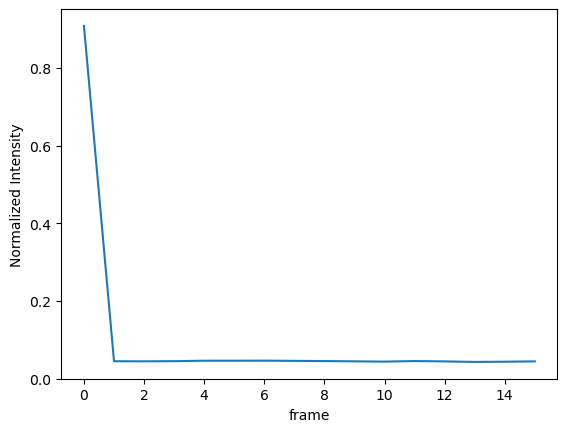

In [109]:
hdu_list = fits.open('C:/Users/isaac/Downloads/cube_norm.fits') #placeholder file - it should take from the created cube when the code gets integrated
data = hdu_list[0].data #pulls cube data from HDU

graph = data[:, chosen_x, chosen_y] #takes a slice for all frames/FIT files at the coordinates you clicked

plt.plot(graph) #plot dot plot
plt.ylabel('Normalized Intensity')
plt.xlabel('frame')
plt.show

In [ ]:
#img_aligned, footprint = aa.register(img, img_rotated, detection_sigma=3.0)
#img_aligned names the aligned image
#footprint is just what image_aligned will be
#aa.register is the acutal function that aligns
#aa.register(image that you match to, image that needs to be shifted, idk about detection I think that specifies how specific the matching algorithm works.)
#turns out we'll be doing this ourselves but I'll leave this here regardless